<h1>Please Extract the zip file contents of shape_predictor_68_face_landmarks.dat.bz2 after running the below cell <h1>

In [52]:
!curl -O http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0 61.0M    0 25655    0     0  25583      0  0:41:43  0:00:01  0:41:42 25706
  0 61.0M    0  214k    0     0   111k      0  0:09:19  0:00:01  0:09:18  112k
  1 61.0M    1  638k    0     0   224k      0  0:04:38  0:00:02  0:04:36  224k
  1 61.0M    1  865k    0     0   231k      0  0:04:30  0:00:03  0:04:27  231k
  2 61.0M    2 1365k    0     0   282k      0  0:03:41  0:00:04  0:03:37  282k
  2 61.0M    2 1663k    0     0   291k      0  0:03:34  0:00:05  0:03:29  347k
  2 61.0M    2 1861k    0     0   274k      0  0:03:48  0:00:06  0:03:42  338k
  3 61.0M    3 2092k    0     0   268k      0  0:03:52  0:00:07  0:03:45  293k
  3 61.0M    3 2289k    0     0   262k      0  0:03:58  0:00:08  0:03:50  285k
  4 61.0M    4 2552k    0     0   260k      0  0:03

<h1>Please Extract the zip file contents of shape_predictor_68_face_landmarks.dat.bz2 before executing the whole ipynb file <h1>

In [53]:
import cv2
import numpy as np
import dlib
import matplotlib.pyplot as plt

In [54]:
def extract_index_nparray(nparray):
    index = None
    for num in nparray[0]:
        index = num
        break
    return index

def detect_landmarks(img, detector, predictor):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = detector(img_gray)
    if len(faces) == 0:
        raise Exception("No faces detected.")
    landmarks = predictor(img_gray, faces[0])
    landmarks_points = [(landmarks.part(n).x, landmarks.part(n).y) for n in range(68)]
    return np.array(landmarks_points, np.int32)


In [55]:
def apply_affine_transform(src, src_triangle, dst_triangle, size):
    warp_mat = cv2.getAffineTransform(np.float32(src_triangle), np.float32(dst_triangle))
    dst = cv2.warpAffine(src, warp_mat, (size[0], size[1]), None, flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
    return dst

def get_triangle_indices(subdiv, points):
    triangles = subdiv.getTriangleList()
    triangles = np.array(triangles, dtype=np.int32)

    indices = []
    for t in triangles:
        pt1 = (t[0], t[1])
        pt2 = (t[2], t[3])
        pt3 = (t[4], t[5])

        index_pt1 = np.where((points == pt1).all(axis=1))
        index_pt1 = extract_index_nparray(index_pt1)

        index_pt2 = np.where((points == pt2).all(axis=1))
        index_pt2 = extract_index_nparray(index_pt2)

        index_pt3 = np.where((points == pt3).all(axis=1))
        index_pt3 = extract_index_nparray(index_pt3)

        if index_pt1 is not None and index_pt2 is not None and index_pt3 is not None:
            indices.append([index_pt1, index_pt2, index_pt3])
    return indices

In [56]:
def apply_delaunay_triangulation(landmarks, img):
    rect = cv2.boundingRect(landmarks)
    subdiv = cv2.Subdiv2D(rect)
    subdiv.insert(landmarks.tolist())
    return get_triangle_indices(subdiv, landmarks)

def warp_and_blend_triangles(img1, img2, triangle_indices, landmarks1, landmarks2):
    img2_new_face = np.zeros_like(img2)
    for triangle_index in triangle_indices:
        tr1_pts = [landmarks1[i] for i in triangle_index]
        tr2_pts = [landmarks2[i] for i in triangle_index]

        rect1 = cv2.boundingRect(np.array(tr1_pts, np.int32))
        rect2 = cv2.boundingRect(np.array(tr2_pts, np.int32))

        cropped_tr1 = img1[rect1[1]: rect1[1] + rect1[3], rect1[0]: rect1[0] + rect1[2]]
        cropped_tr2_mask = np.zeros((rect2[3], rect2[2]), np.uint8)
        
        points1 = np.array([[tr1_pts[i][0] - rect1[0], tr1_pts[i][1] - rect1[1]] for i in range(3)], np.int32)
        points2 = np.array([[tr2_pts[i][0] - rect2[0], tr2_pts[i][1] - rect2[1]] for i in range(3)], np.int32)

        cv2.fillConvexPoly(cropped_tr2_mask, points2, 255)

        M = cv2.getAffineTransform(np.float32(points1), np.float32(points2))
        warped_triangle = cv2.warpAffine(cropped_tr1, M, (rect2[2], rect2[3]), None, flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
        warped_triangle = cv2.bitwise_and(warped_triangle, warped_triangle, mask=cropped_tr2_mask)

        img2_new_face_rect_area = img2_new_face[rect2[1]: rect2[1] + rect2[3], rect2[0]: rect2[0] + rect2[2]]
        img2_new_face_rect_area_gray = cv2.cvtColor(img2_new_face_rect_area, cv2.COLOR_BGR2GRAY)
        _, mask_triangles_designed = cv2.threshold(img2_new_face_rect_area_gray, 1, 255, cv2.THRESH_BINARY_INV)
        warped_triangle = cv2.bitwise_and(warped_triangle, warped_triangle, mask=mask_triangles_designed)
        img2_new_face[rect2[1]: rect2[1] + rect2[3], rect2[0]: rect2[0] + rect2[2]] = cv2.add(img2_new_face_rect_area, warped_triangle)
    
    return img2_new_face


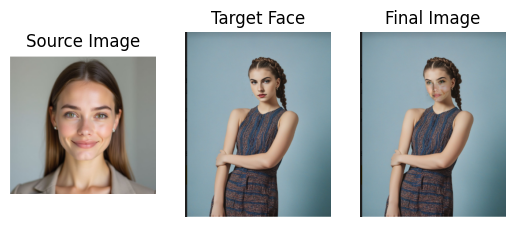

In [57]:
def seamless_cloning(img1, img2, img2_new_face, convexhull2):
    img2_face_mask = np.zeros_like(img2[:, :, 0])
    img2_head_mask = cv2.fillConvexPoly(img2_face_mask, convexhull2, 255)
    img2_face_mask = cv2.bitwise_not(img2_head_mask)
    
    img2_head_noface = cv2.bitwise_and(img2, img2, mask=img2_face_mask)
    result = cv2.add(img2_head_noface, img2_new_face)

    (x, y, w, h) = cv2.boundingRect(convexhull2)
    center_face2 = (int((x + x + w) / 2), int((y + y + h) / 2))

    seamlessclone = cv2.seamlessClone(result, img2, img2_head_mask, center_face2, cv2.NORMAL_CLONE)
    return seamlessclone

def show_images(images, titles):
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.show()
    
def main():
    img1 = cv2.imread("source.png")
    img2 = cv2.imread("target.png")
    detector = dlib.get_frontal_face_detector()
    #Please Open the zip file shape_predictor_68_face_landmarks.dat.bz2 before executing 
    predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")
    try:
        landmarks1 = detect_landmarks(img1, detector, predictor)
        landmarks2 = detect_landmarks(img2, detector, predictor)
    except Exception as e:
        print(f"Error: {e}")
        return
    convexhull2 = cv2.convexHull(landmarks2)
    triangle_indices = apply_delaunay_triangulation(landmarks1, img1)
    img2_new_face = warp_and_blend_triangles(img1, img2, triangle_indices, landmarks1, landmarks2)
    seamlessclone = seamless_cloning(img1, img2, img2_new_face, convexhull2)
    show_images([img1, img2, seamlessclone], ["Source Image", "Target Face", "Final Image"])

if __name__ == "__main__":
    main()